In [1]:
import numpy as np 
import pandas as pd

In [2]:
df = pd.read_csv("seattle-weather.csv")
df.head()

,date,precipitation,temp_max,temp_min,wind,weather
0,2012-01-01,0.0,12.8,5.0,4.7,drizzle
1,2012-01-02,10.9,10.6,2.8,4.5,rain
2,2012-01-03,0.8,11.7,7.2,2.3,rain
3,2012-01-04,20.3,12.2,5.6,4.7,rain
4,2012-01-05,1.3,8.9,2.8,6.1,rain


In [3]:
df['date'] = pd.to_datetime(df['date'])

df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day

In [4]:
x=df.drop(columns=['date','weather'],axis=1)
y=df['weather']

In [5]:
x

,precipitation,temp_max,temp_min,wind,month,day
0,0.0,12.8,5.0,4.7,1,1
1,10.9,10.6,2.8,4.5,1,2
2,0.8,11.7,7.2,2.3,1,3
3,20.3,12.2,5.6,4.7,1,4
4,1.3,8.9,2.8,6.1,1,5
...,...,...,...,...,...,...
1456,8.6,4.4,1.7,2.9,12,27
1457,1.5,5.0,1.7,1.3,12,28
1458,0.0,7.2,0.6,2.6,12,29
1459,0.0,5.6,-1.0,3.4,12,30


In [6]:
y

0       drizzle
1          rain
2          rain
3          rain
4          rain
         ...   
1456       rain
1457       rain
1458        fog
1459        sun
1460        sun
Name: weather, Length: 1461, dtype: object

In [7]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['weather'] = le.fit_transform(df['weather'])

mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print("Label Mapping:",mapping)

Label Mapping: {'drizzle': 0, 'fog': 1, 'rain': 2, 'snow': 3, 'sun': 4}


In [8]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42)


Model Accuracies:

Logistic Regression Accuracy: 0.8328

Logistic Regression Confusion Matrix:
[[  0   0   0   0   9]
 [  0   0   0   0  25]
 [  0   0 112   0   8]
 [  0   0   7   1   0]
 [  0   0   0   0 131]]



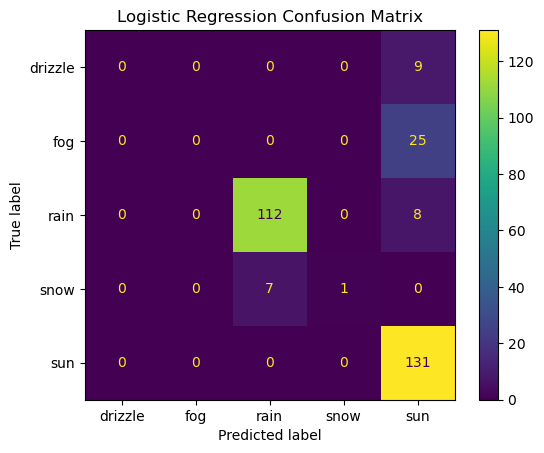

Random Forest Accuracy: 0.8498

Random Forest Confusion Matrix:
[[  1   0   0   0   8]
 [  0   5   0   0  20]
 [  0   0 111   1   8]
 [  0   0   6   2   0]
 [  0   1   0   0 130]]



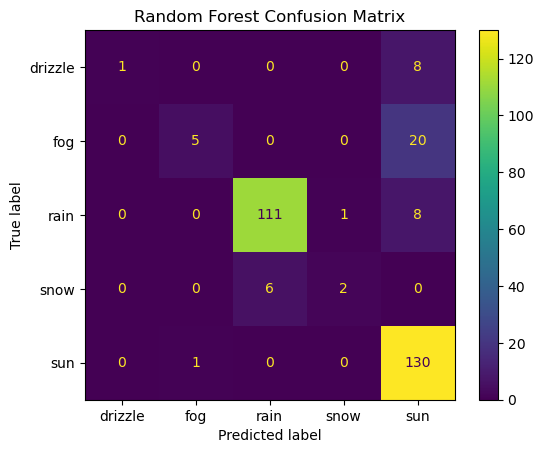

SVM Accuracy: 0.7577

SVM Confusion Matrix:
[[  0   0   1   0   8]
 [  0   0   3   0  22]
 [  0   0  98   0  22]
 [  0   0   6   0   2]
 [  0   0   7   0 124]]



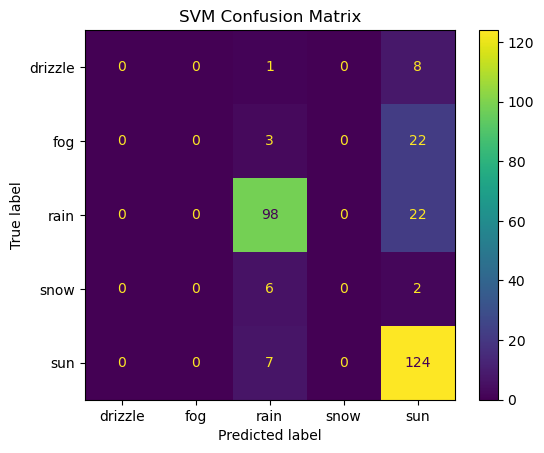

KNN Accuracy: 0.7201

KNN Confusion Matrix:
[[  1   2   3   0   3]
 [  1   2   6   0  16]
 [  1   4  99   0  16]
 [  1   0   6   0   1]
 [  2   4  16   0 109]]



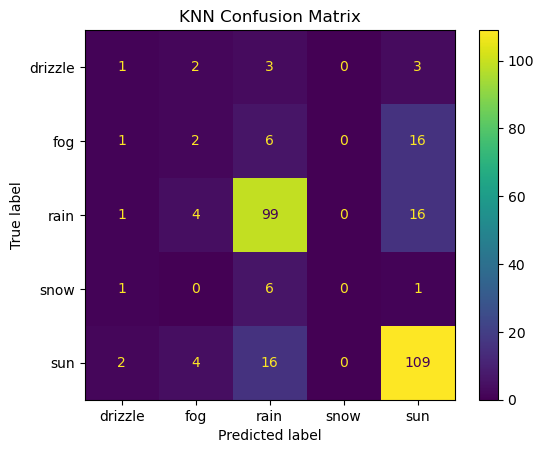

Decision Tree Accuracy: 0.7440

Decision Tree Confusion Matrix:
[[  2   1   1   0   5]
 [  3   3   2   0  17]
 [  0   0 108   5   7]
 [  0   0   5   3   0]
 [ 10  13   6   0 102]]



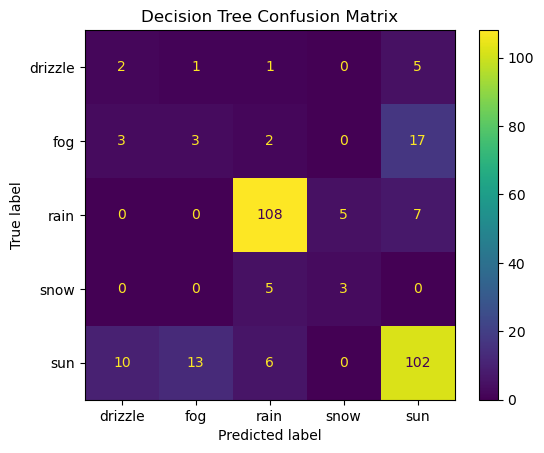


Best Model: Random Forest with accuracy 0.8498


In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

models = [
    ('Logistic Regression', LogisticRegression(max_iter=1000)),
    ('Random Forest', RandomForestClassifier()),
    ('SVM', SVC(probability=True)),
    ('KNN', KNeighborsClassifier()),
    ('Decision Tree', DecisionTreeClassifier())
]
# Train & evaluate
best_model = None
best_accuracy = 0
best_name = ""

print("\nModel Accuracies:\n")

for name, model in models:
    model.fit(x_train, y_train)

    predictions = model.predict(x_test)

    accuracy = accuracy_score(y_test, predictions)
    
    print(f"{name} Accuracy: {accuracy:.4f}")

     # Confusion Matrix (print)
    cm = confusion_matrix(y_test, predictions)
    print(f"\n{name} Confusion Matrix:\n{cm}\n")

    # Confusion Matrix (plot)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
    disp.plot()
    plt.title(f"{name} Confusion Matrix")
    plt.show()

    # Select best model
    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_model = model
        best_name = name

print(f"\nBest Model: {best_name} with accuracy {best_accuracy:.4f}")

In [10]:
import pandas as pd

input_data = {
    'precipitation': [10.0],
    'temp_max': [25.0],
    'temp_min': [16.0],
    'wind': [10.5],
    'month': [2],
    'day': [25]
}

test_case = pd.DataFrame(input_data)

In [12]:
pred = best_model.predict(test_case)
# Check if prediction is numeric or already string
if isinstance(pred[0], (int, np.integer)):
    pred_label = le.inverse_transform(pred)
else:
    pred_label = pred  # already label

print(f"\nPrediction using best model ({best_name}): {pred_label[0]}")


Prediction using best model (Random Forest): rain



Probabilities:
drizzle: 1.00%
fog: 1.00%
rain: 90.00%
snow: 0.00%
sun: 8.00%


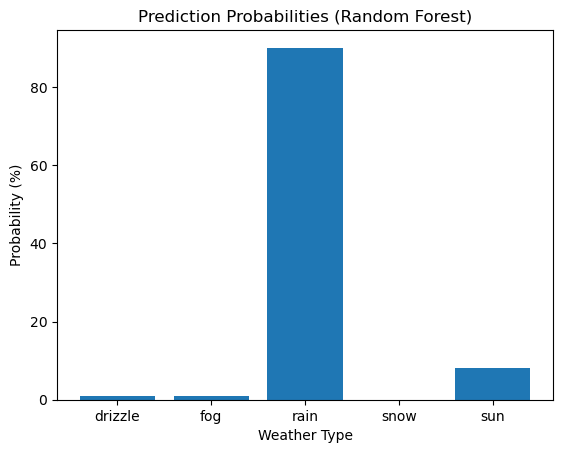

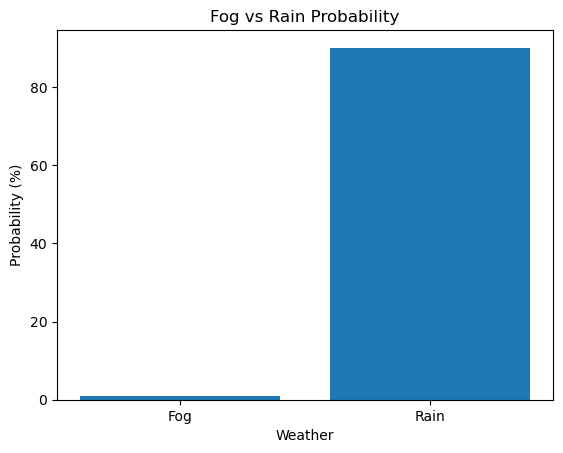

In [13]:
import matplotlib.pyplot as plt
if hasattr(best_model, "predict_proba"):
    probs = best_model.predict_proba(test_case)[0] * 100

    # FIXED LINE
    classes = best_model.classes_

    print("\nProbabilities:")
    for c, p in zip(classes, probs):
        print(f"{c}: {p:.2f}%")

    # Plot all classes
    plt.figure()
    plt.bar(classes, probs)
    plt.xlabel("Weather Type")
    plt.ylabel("Probability (%)")
    plt.title(f"Prediction Probabilities ({best_name})")
    plt.show()

    # Fog vs Rain graph
    labels = []
    values = []

    for c, p in zip(classes, probs):
        if str(c).lower() in ['fog', 'rain']:
            labels.append(str(c).capitalize())
            values.append(p)

    plt.figure()
    plt.bar(labels, values)
    plt.xlabel("Weather")
    plt.ylabel("Probability (%)")
    plt.title("Fog vs Rain Probability")
    plt.show()